# Course 3 — K-Means Clustering
===============================

K-Means is an unsupervised learning algorithm that groups unlabeled data points into $K$ distinct clusters by minimizing within-cluster variance.

### In this notebook, we will explore:
1. **K-Means from Scratch**: Implementing random initialization, cluster assignment, and centroid updating.
2. **Elbow Method**: Evaluating within-cluster distortion (Inertia) to select the optimal number of clusters $K$.
3. **Silhouette Score**: Measuring cluster cohesion and separation quality.

In [1]:
import sys
from pathlib import Path
# Add repository root to sys.path dynamically
project_root = Path(".").resolve()
while project_root.name and not (project_root / "utils").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from utils.helpers import make_blobs


## 1. Data Generation

We generate a 2D dataset with 3 isotropic Gaussian blobs to evaluate our clustering results.

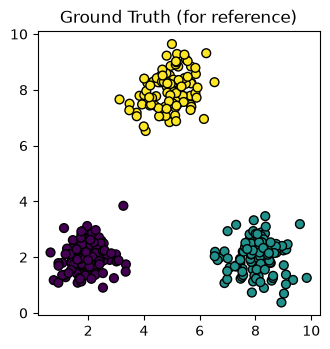

In [2]:
X, y_true = make_blobs(n=300, centers=3, seed=42)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap="viridis", edgecolor="k", s=40)
plt.title("Ground Truth (for reference)")
plt.gca().set_aspect("equal")

## 2. K-Means Implementation from Scratch

### Distortion (Inertia) Cost Function
The objective of K-Means is to minimize the distortion function, which measures the sum of squared distances from each data point to its assigned cluster centroid:
$$J(c^{(1)}, \dots, c^{(m)}, \mu_1, \dots, \mu_K) = \frac{1}{m} \sum_{i=1}^m ||x^{(i)} - \mu_{c^{(i)}}||^2$$
where $c^{(i)}$ is the index of the cluster ($1, \dots, K$) to which sample $x^{(i)}$ is assigned, and $\mu_{j}$ is the position of centroid $j$.

### Optimization Steps:
1. **Cluster Assignment Step**: Minimize $J$ with respect to $c^{(1)}, \dots, c^{(m)}$ by assigning each sample to the nearest centroid:
   $$c^{(i)} := \arg\min_j ||x^{(i)} - \mu_j||^2$$
2. **Centroid Update Step**: Minimize $J$ with respect to centroids $\mu_1, \dots, \mu_K$ by setting each centroid to the mean of all points assigned to it:
   $$\mu_j := \frac{1}{|S_j|} \sum_{i \in S_j} x^{(i)}$$
   where $S_j$ is the set of indices of samples assigned to centroid $j$.

In [3]:
# ── K-Means Implementation from Scratch ───────────────────────────────

print("── K-Means from Scratch ──")


def initialize_centroids(X, k, seed=42):
    """Randomly pick k points as centroids."""
    rng = np.random.default_rng(seed)
    return X[rng.choice(X.shape[0], k, replace=False)]


def assign_clusters(X, centroids):
    """Assign each point to nearest centroid (Euclidean distance)."""
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)


def update_centroids(X, labels, k):
    """Compute mean of points in each cluster as new centroid."""
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])


def kmeans(X, k, n_iters=100, seed=42):
    """Full K-Means algorithm."""
    centroids = initialize_centroids(X, k, seed)
    for i in range(n_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        if np.allclose(centroids, new_centroids):
            print(f"  Converged at iteration {i + 1}")
            break
        centroids = new_centroids
    return labels, centroids

── K-Means from Scratch ──


  Converged at iteration 3
  Centroids:
[[8.03720999 1.98818641]
 [1.99067368 1.97080886]
 [4.9297524  7.98407806]]


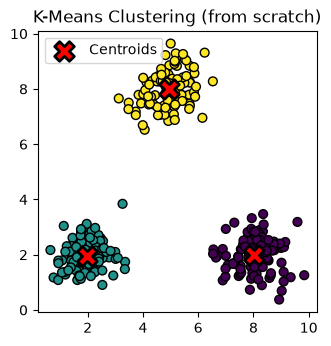

In [4]:
labels, centroids = kmeans(X, k=3)

print(f"  Centroids:\n{centroids}")

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", edgecolor="k", s=40)
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", marker="X",
            s=200, linewidths=2, edgecolors="black", label="Centroids")
plt.title("K-Means Clustering (from scratch)")
plt.legend()
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

## 3. The Elbow Method

Determining the optimal number of clusters $K$ is a major challenge in unsupervised clustering. The **Elbow Method** runs K-Means over a range of cluster counts (e.g. $1$ to $10$) and plots the resulting distortion (Inertia). We choose the value of $K$ at the "elbow" point—where adding another cluster yields a substantially smaller drop in distortion.


── Elbow Method ──


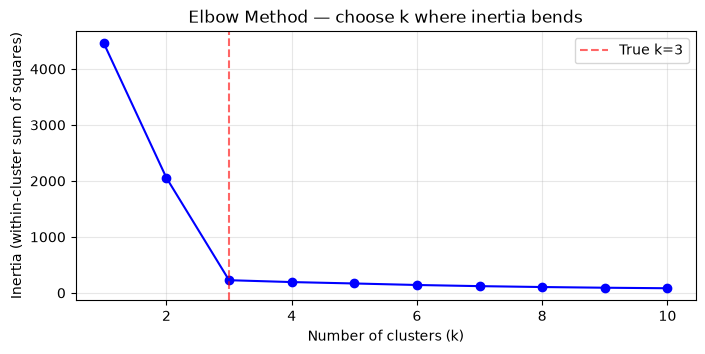

In [5]:
# ── Elbow Method ──────────────────────────────────────────────────────

print("\n── Elbow Method ──")

inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 3.5))
plt.plot(K_range, inertias, "bo-", linewidth=1.5)
plt.axvline(3, color="red", ls="--", alpha=0.6, label="True k=3")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method — choose k where inertia bends")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Silhouette Analysis

The **Silhouette Coefficient** measures how close a sample is to points in its own cluster compared to points in the nearest neighboring cluster:
$$s^{(i)} = \frac{b^{(i)} - a^{(i)}}{\max(a^{(i)}, b^{(i)})}$$
where:
- $a^{(i)}$ is the mean intra-cluster distance between sample $i$ and all other points in the same cluster.
- $b^{(i)}$ is the mean nearest-cluster distance between sample $i$ and points in the closest neighboring cluster.

The score ranges from $-1$ to $+1$, where a higher score indicates that the sample is well-clustered (close to its own cluster and far from others).

In [6]:
# ── Silhouette Score ──────────────────────────────────────────────────

print("\n── Silhouette Score ──")

for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"  k={k}: Silhouette = {score:.4f}")


── Silhouette Score ──
  k=2: Silhouette = 0.5882
  k=3: Silhouette = 0.8219
  k=4: Silhouette = 0.6670
  k=5: Silhouette = 0.4953
  k=6: Silhouette = 0.3419


## Key Takeaways

- **Iterative Optimization**: K-Means alternates between cluster assignment ($c^{(i)}$ minimizing distortion given centroids) and centroid updating (centroids minimizing distortion given assignments).
- **Local Minima Sensitivity**: K-Means is highly sensitive to the initial random centroid coordinates. To remedy this, run multiple times with different seeds (`n_init` parameter in Scikit-Learn) and select the one with the lowest distortion.
- **Elbow Criterion**: Select the cluster count $K$ where the distortion reduction rate flattens out.
- **Silhouette Analysis**: Evaluates clusters' thickness, cohesion, and separation on a range of $[-1, 1]$. Higher is better.

In [7]:
# ── Key Takeaways ─────────────────────────────────────────────────────
print("""
╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • K-Means: iterative centroid-based clustering                ║
║   1. Randomly initialise k centroids                          ║
║   2. Assign each point to nearest centroid                    ║
║   3. Recompute centroids as mean of cluster points            ║
║   4. Repeat until convergence                                 ║
║ • Distortion / Inertia: sum of squared distances to centroid  ║
║ • Elbow Method: plot k vs inertia, pick the "bend" point      ║
║ • Silhouette Score: measures cluster cohesion & separation     ║
║ → ranges [-1, 1]; higher = better                             ║
║ • K-Means is sensitive to initialisation (run multiple times) ║
╚════════════════════════════════════════════════════════════════╝
""")


╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • K-Means: iterative centroid-based clustering                ║
║   1. Randomly initialise k centroids                          ║
║   2. Assign each point to nearest centroid                    ║
║   3. Recompute centroids as mean of cluster points            ║
║   4. Repeat until convergence                                 ║
║ • Distortion / Inertia: sum of squared distances to centroid  ║
║ • Elbow Method: plot k vs inertia, pick the "bend" point      ║
║ • Silhouette Score: measures cluster cohesion & separation     ║
║ → ranges [-1, 1]; higher = better                             ║
║ • K-Means is sensitive to initialisation (run multiple times) ║
╚════════════════════════════════════════════════════════════════╝

